In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Lets load the Boston House Pricing Dataset

Loading the dataset from the Kaggle CSV file (`BostonHousing.csv`) instead of `sklearn.datasets.load_boston` (which was removed in scikit-learn 1.2 due to ethical concerns about the dataset).

> Download from: https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset

**IMPORTANT: Make sure BostonHousing.csv is in the same directory as this notebook!**

This version of the dataset uses **lowercase column names** (`crim`, `zn`, ..., `medv`).

In [2]:
# Load the Kaggle Boston Housing CSV
df = pd.read_csv("BostonHousing.csv")

# Normalize column names to UPPERCASE so the rest of the notebook can use the
# canonical names (CRIM, ZN, ..., MEDV). This way you can drop in any version
# of the Boston dataset (lowercase or uppercase) without changing anything else.
df.columns = [c.upper() for c in df.columns]

print(f"Dataset loaded successfully! Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset loaded successfully! Shape: (506, 14)
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# The Kaggle version contains some missing values — fill them with the column median
print("Missing values before filling:")
print(df.isnull().sum())
print("\nFilling missing values with median...")
df = df.fillna(df.median(numeric_only=True))
print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values before filling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         5
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Filling missing values with median...

Missing values after filling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
# Build a simple object with the same attributes as the old sklearn Bunch
# (.data, .target, .feature_names) so the rest of the notebook works unchanged.
from types import SimpleNamespace

feature_names = np.array([c for c in df.columns if c != "MEDV"])
boston = SimpleNamespace(
    data=df[feature_names].values,
    target=df["MEDV"].values,
    feature_names=feature_names,
    DESCR="Boston House Prices dataset (loaded from Kaggle CSV)."
)
print(f"Number of features: {len(feature_names)}")
print(f"Feature names: {list(feature_names)}")

Number of features: 13
Feature names: [np.str_('CRIM'), np.str_('ZN'), np.str_('INDUS'), np.str_('CHAS'), np.str_('NOX'), np.str_('RM'), np.str_('AGE'), np.str_('DIS'), np.str_('RAD'), np.str_('TAX'), np.str_('PTRATIO'), np.str_('B'), np.str_('LSTAT')]


In [5]:
boston.__dict__.keys()

dict_keys(['data', 'target', 'feature_names', 'DESCR'])

In [6]:
## Lets check the description of the dataset
print(boston.DESCR)

Boston House Prices dataset (loaded from Kaggle CSV).


In [7]:
print("First 5 rows of data:")
print(boston.data[:5])

First 5 rows of data:
[[6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01 6.5750e+00
  6.5200e+01 4.0900e+00 1.0000e+00 2.9600e+02 1.5300e+01 3.9690e+02
  4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 6.4210e+00
  7.8900e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9690e+02
  9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01 7.1850e+00
  6.1100e+01 4.9671e+00 2.0000e+00 2.4200e+02 1.7800e+01 3.9283e+02
  4.0300e+00]
 [3.2370e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 6.9980e+00
  4.5800e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 3.9463e+02
  2.9400e+00]
 [6.9050e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 7.1470e+00
  5.4200e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 3.9690e+02
  5.3300e+00]]


In [8]:
print("First 5 target values:")
print(boston.target[:5])

First 5 target values:
[24.  21.6 34.7 33.4 36.2]


In [9]:
print("Feature names:")
print(boston.feature_names)

Feature names:
['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']


## Preparing The Dataset

In [10]:
dataset=pd.DataFrame(boston.data,columns=boston.feature_names)

In [11]:
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [12]:
dataset['Price']=boston.target

In [13]:
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  Price    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [15]:
## Summarizing The Stats of the data
dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.283587,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702126,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.618750,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [16]:
## Check the missing Values
dataset.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
Price      0
dtype: int64

In [17]:
### Exploratory Data Analysis
## Correlation
dataset.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.218823,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311007,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391654,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091722,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.301609,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.218823,0.311007,-0.391654,0.091722,-0.301609,1.000000,-0.239854,0.201815,-0.209753,-0.291581,-0.356146,0.127547,-0.614631,0.695668
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.239854,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.201815,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209753,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.291581,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


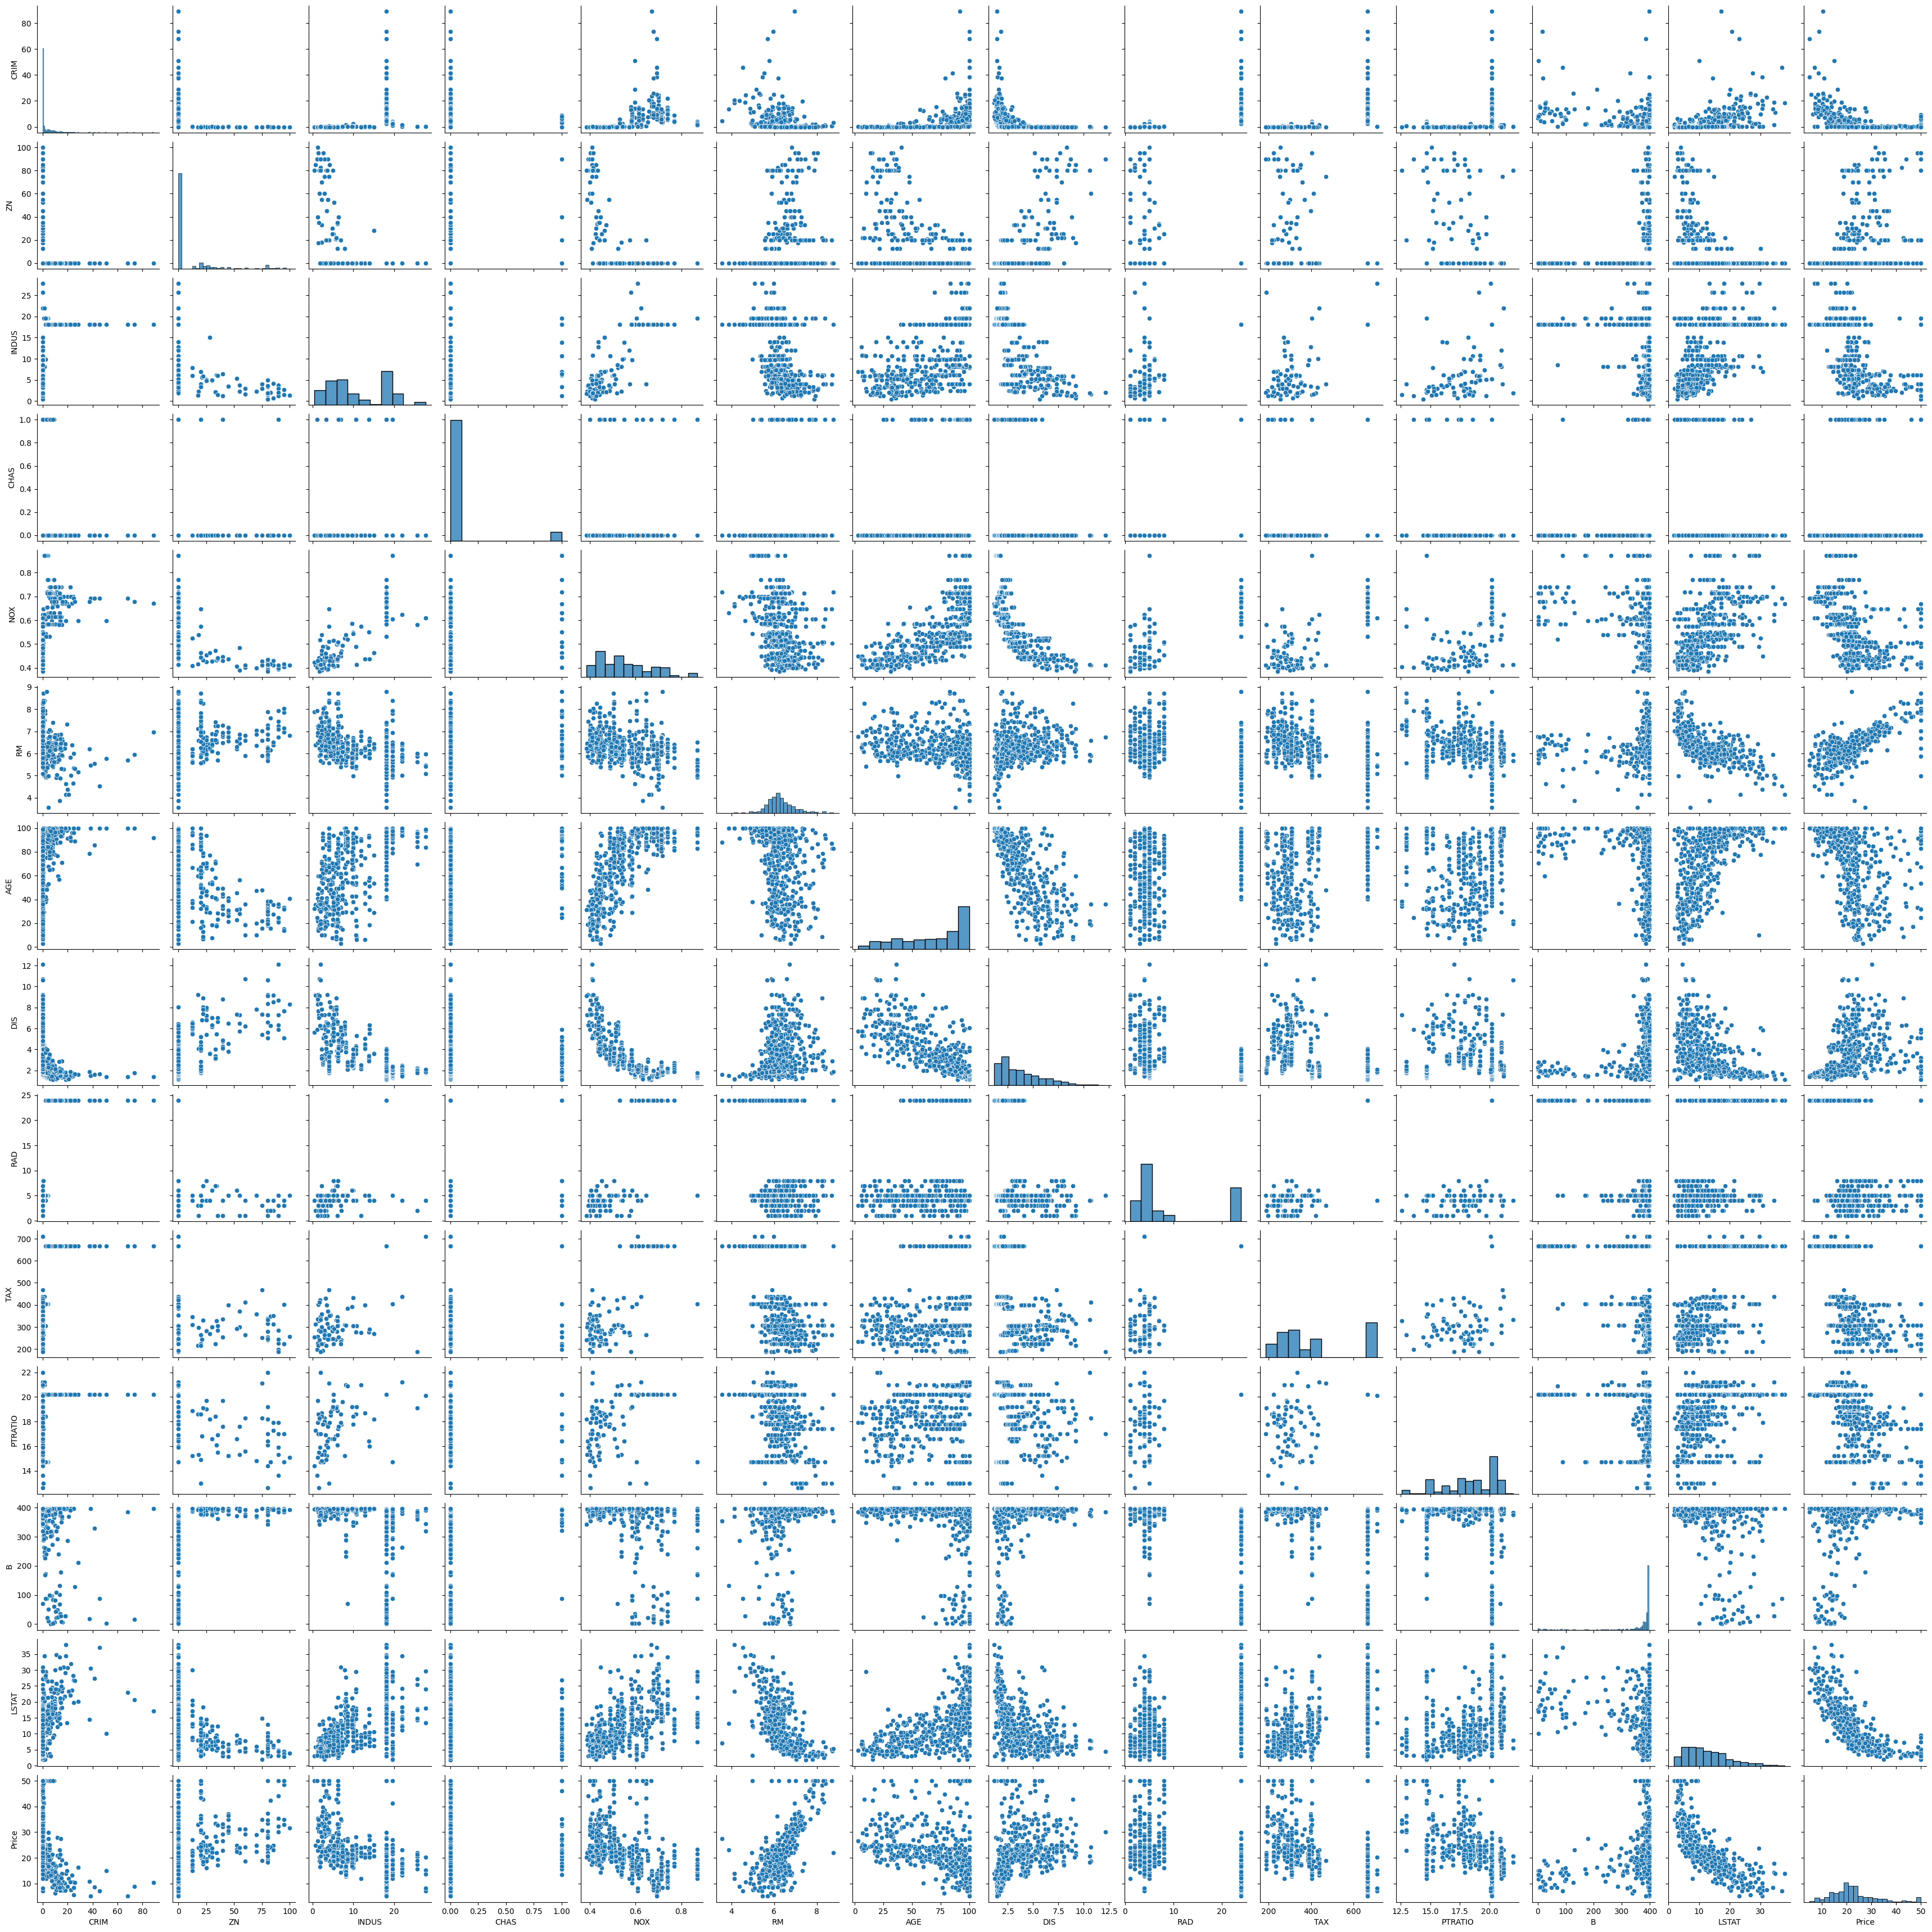

In [18]:
import seaborn as sns
sns.pairplot(dataset)

## Analyzing The Correlated Features

In [19]:
dataset.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.218823,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311007,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391654,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091722,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.301609,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.218823,0.311007,-0.391654,0.091722,-0.301609,1.000000,-0.239854,0.201815,-0.209753,-0.291581,-0.356146,0.127547,-0.614631,0.695668
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.239854,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.201815,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209753,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.291581,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


Text(0, 0.5, 'Price')

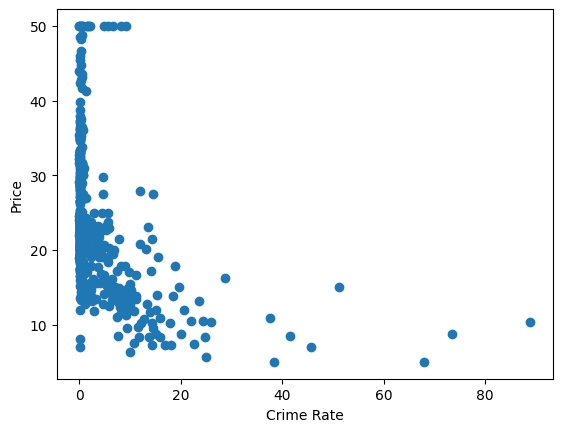

In [20]:
plt.scatter(dataset['CRIM'],dataset['Price'])
plt.xlabel("Crime Rate")
plt.ylabel("Price")

Text(0, 0.5, 'Price')

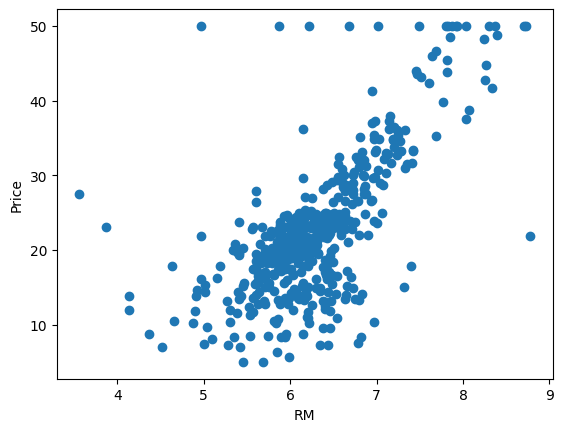

In [21]:
plt.scatter(dataset['RM'],dataset['Price'])
plt.xlabel("RM")
plt.ylabel("Price")

<Axes: xlabel='RM', ylabel='Price'>

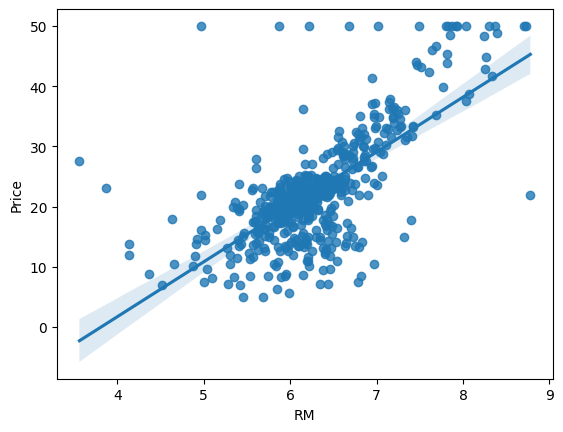

In [22]:
import seaborn as sns
sns.regplot(x="RM",y="Price",data=dataset)

<Axes: xlabel='LSTAT', ylabel='Price'>

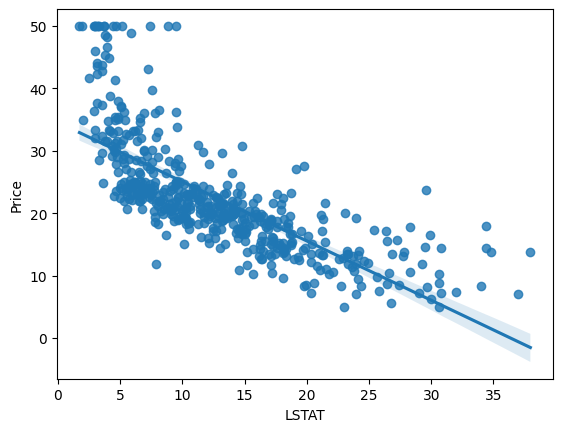

In [23]:
sns.regplot(x="LSTAT",y="Price",data=dataset)

<Axes: xlabel='CHAS', ylabel='Price'>

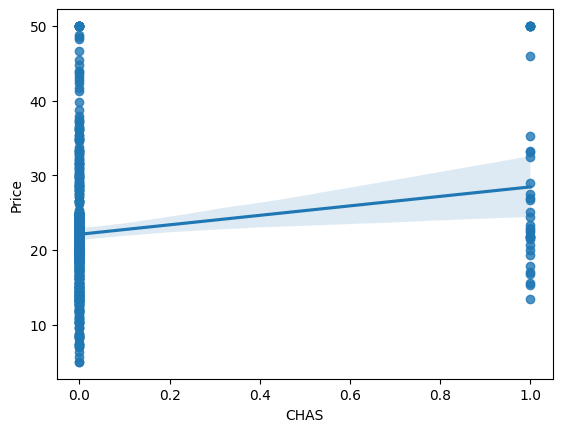

In [24]:
sns.regplot(x="CHAS",y="Price",data=dataset)

<Axes: xlabel='PTRATIO', ylabel='Price'>

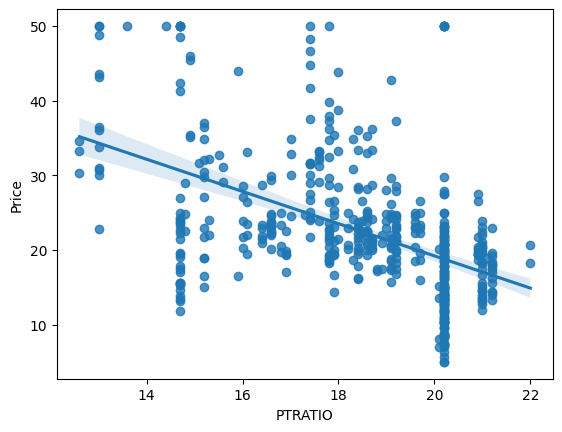

In [25]:
sns.regplot(x="PTRATIO",y="Price",data=dataset)

In [26]:
## Independent and Dependent features
## CRITICAL: We explicitly drop the 'Price' column to guarantee X has 13 features only.
## (Using column names instead of iloc avoids any chance of off-by-one errors.)

X = dataset.drop(columns=['Price'])    # 13 features
y = dataset['Price']                   # target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X columns ({len(X.columns)}): {list(X.columns)}")
assert X.shape[1] == 13, f"Expected 13 features, got {X.shape[1]}"
print("✓ X has exactly 13 features")

X shape: (506, 13)
y shape: (506,)
X columns (13): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
✓ X has exactly 13 features


In [27]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [28]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: Price, dtype: float64

In [29]:
##Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (354, 13)
X_test shape: (152, 13)
y_train shape: (354,)
y_test shape: (152,)


In [30]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21
116,0.13158,0.0,10.01,0.0,0.547,6.176,72.5,2.7301,6.0,432.0,17.8,393.30,12.04
45,0.17142,0.0,6.91,0.0,0.448,5.682,33.8,5.1004,3.0,233.0,17.9,396.90,10.21
16,1.05393,0.0,8.14,0.0,0.538,5.935,29.3,4.4986,4.0,307.0,21.0,386.85,6.58
468,15.57570,0.0,18.10,0.0,0.580,5.926,71.0,2.9084,24.0,666.0,20.2,368.74,18.13


In [31]:
X_test.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,4.05,0.0,0.510,6.416,84.1,2.6463,5.0,296.0,16.6,395.50,9.04
274,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4.0,254.0,17.6,396.90,3.53
491,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07
72,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4.0,305.0,19.2,390.91,5.52
452,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24.0,666.0,20.2,385.09,17.27


In [32]:
## Standardize the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
print("Scaler created successfully")

Scaler created successfully


In [33]:
# Fit the scaler ONLY on training features (must be exactly 13)
assert X_train.shape[1] == 13, f"X_train has {X_train.shape[1]} columns, expected 13!"

X_train = scaler.fit_transform(X_train)
print(f"X_train scaled. Shape: {X_train.shape}")
print(f"✓ Scaler was fit on {scaler.n_features_in_} features")
assert scaler.n_features_in_ == 13, "Scaler fit on wrong number of features!" 

X_train scaled. Shape: (354, 13)
✓ Scaler was fit on 13 features


In [34]:
X_test=scaler.transform(X_test)
print(f"X_test scaled. Shape: {X_test.shape}")

X_test scaled. Shape: (152, 13)


In [35]:
import pickle
import os

# Remove any stale pickle files from previous runs to guarantee a clean save
for old in ['scaling.pkl', 'regmodel.pkl']:
    if os.path.exists(old):
        os.remove(old)
        print(f"Removed stale {old}")

pickle.dump(scaler, open('scaling.pkl', 'wb'))
print("✓ Scaler saved to scaling.pkl")
print(f"✓ Saved scaler expects {scaler.n_features_in_} features (must be 13)")
assert scaler.n_features_in_ == 13

✓ Scaler saved to scaling.pkl
✓ Saved scaler expects 13 features (must be 13)


In [36]:
print("First 5 rows of scaled X_train:")
print(X_train[:5])

First 5 rows of scaled X_train:
[[-0.41425879 -0.50512499 -1.29214218 -0.28154625 -0.85108479  0.14522035
  -0.365584    1.08162833 -0.74617905 -1.11279004  0.18727079  0.39651419
  -1.01531611]
 [-0.40200818 -0.50512499 -0.16208345 -0.28154625 -0.08796708 -0.20856833
   0.13394078 -0.48787608 -0.39846419  0.15008778 -0.21208981  0.3870674
  -0.05366252]
 [-0.39721053 -0.50512499 -0.60948856 -0.28154625 -0.93682836 -0.89664553
  -1.26690045  0.62859591 -0.74617905 -1.0466393  -0.16771641  0.42854113
  -0.31132373]
 [-0.29093623 -0.50512499 -0.43196976 -0.28154625 -0.16513629 -0.54424972
  -1.42978896  0.3451327  -0.6302741  -0.60162521  1.20785901  0.31276028
  -0.82242219]
 [ 1.45781561 -0.50512499  1.00549958 -0.28154625  0.19498668 -0.55678554
   0.07964461 -0.40389221  1.68782492  1.5572945   0.8528718   0.10412434
   0.8038002 ]]


In [37]:
print("First 5 rows of scaled X_test:")
print(X_test[:5])

First 5 rows of scaled X_test:
[[-0.406801   -0.50512499 -1.02225586 -0.28154625 -0.40521827  0.12572018
   0.55383118 -0.52734802 -0.51436915 -0.66777595 -0.74457062  0.41241246
  -0.47605794]
 [-0.41105674  1.26662874 -0.68165068  3.55181427 -0.94540271  0.60208132
  -1.29947815  0.14683092 -0.6302741  -0.92035152 -0.30083661  0.42854113
  -1.25185755]
 [-0.4051199  -0.50512499  2.39678516 -0.28154625  0.44364301 -0.47739201
   1.08593366 -0.89390015 -0.6302741   1.82791117  0.8084984   0.35031705
   0.79535229]
 [-0.40681786 -0.50512499 -0.04662407 -0.28154625 -1.23693083 -0.36317677
  -2.20803409  0.71663059 -0.6302741  -0.61365262  0.4091378   0.35953344
  -0.97166858]
 [ 0.19511899 -0.50512499  1.00549958 -0.28154625  1.33537606 -0.04003121
   0.83255152 -0.65834024  1.68782492  1.5572945   0.8528718   0.29248423
   0.68271351]]


## Model Training

In [38]:
from sklearn.linear_model import LinearRegression
print("LinearRegression imported successfully")

LinearRegression imported successfully


In [39]:
regression=LinearRegression()
print("LinearRegression model created")

LinearRegression model created


In [40]:
regression.fit(X_train,y_train)
print("✓ Model training completed!")

✓ Model training completed!


In [41]:
## print the coefficients and the intercept
print("Coefficients:")
print(regression.coef_)

Coefficients:
[-1.10860816  0.80893522  0.35254655  0.81427573 -1.7987809   2.91242475
 -0.29076872 -2.92810343  2.0905571  -1.44321462 -2.05736701  1.02486028
 -3.88209347]


In [42]:
print("Intercept:")
print(regression.intercept_)

Intercept:
23.015819209039545


In [43]:
## on which parameters the model has been trained
regression.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [44]:
### Prediction With Test Data
reg_pred=regression.predict(X_test)
print(f"Predictions generated for {len(reg_pred)} samples")

Predictions generated for 152 samples


In [45]:
print("First 10 predictions:")
print(reg_pred[:10])

First 10 predictions:
[28.63772945 36.47857848 15.43766279 25.39025687 18.85880766 23.15353596
 17.39916824 14.08796831 23.04414907 20.59203273]


## Assumptions

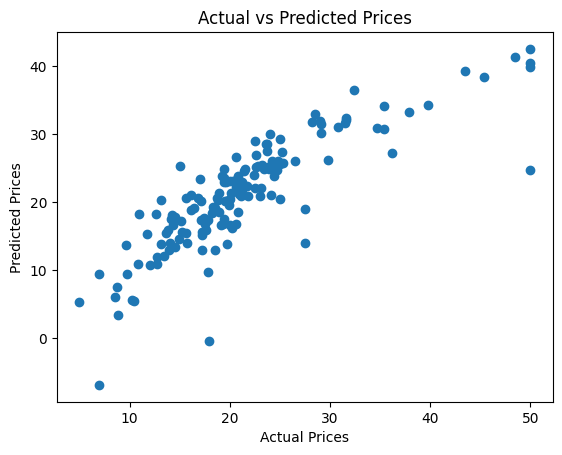

In [46]:
## plot a scatter plot for the prediction
plt.scatter(y_test,reg_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [47]:
## Residuals
residuals=y_test-reg_pred
print(f"Residuals calculated. Shape: {residuals.shape}")

Residuals calculated. Shape: (152,)


In [48]:
print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
173   -5.037729
274   -4.078578
491   -1.837663
72    -2.590257
452   -2.758808
76    -3.153536
316    0.400832
140   -0.087968
471   -3.444149
500   -3.792033
Name: Price, dtype: float64


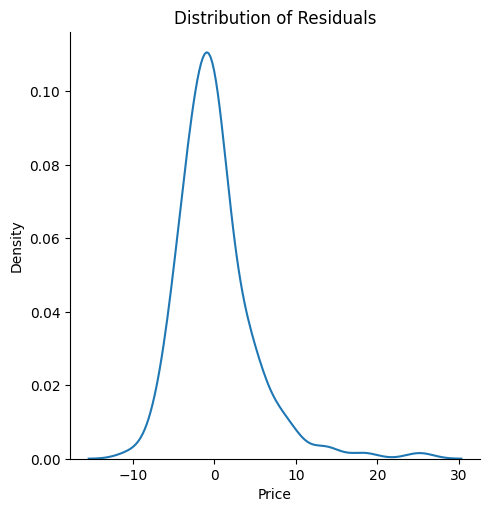

In [49]:
## Plot this residuals 
sns.displot(residuals,kind="kde")
plt.title("Distribution of Residuals")
plt.show()

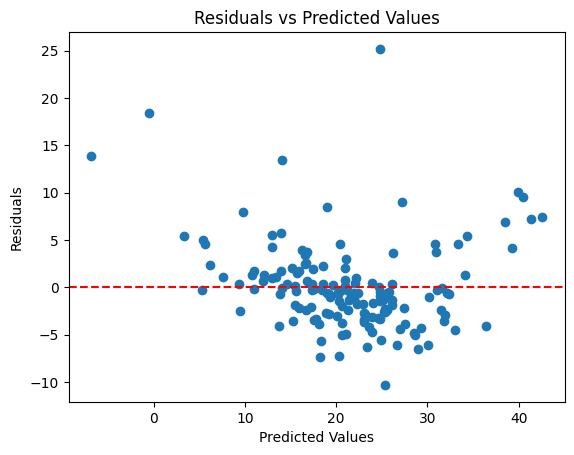

In [50]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(reg_pred,residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

In [51]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,reg_pred)
mse = mean_squared_error(y_test,reg_pred)
rmse = np.sqrt(mean_squared_error(y_test,reg_pred))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 3.1761
Mean Squared Error (MSE): 21.6188
Root Mean Squared Error (RMSE): 4.6496


## R square and adjusted R square


Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares


In [52]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(f"R² Score: {score:.4f}")

R² Score: 0.7099


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [53]:
#display adjusted R-squared
adj_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(f"Adjusted R² Score: {adj_r2:.4f}")

Adjusted R² Score: 0.6825


## New Data Prediction

In [54]:
print("Sample data point (first row):")
print(boston.data[0])
print(f"\nReshaped for prediction: {boston.data[0].reshape(1,-1).shape}")

Sample data point (first row):
[6.320e-03 1.800e+01 2.310e+00 0.000e+00 5.380e-01 6.575e+00 6.520e+01
 4.090e+00 1.000e+00 2.960e+02 1.530e+01 3.969e+02 4.980e+00]

Reshaped for prediction: (1, 13)


In [55]:
##transformation of new data
sample_transformed = scaler.transform(boston.data[0].reshape(1,-1))
print("Transformed sample data:")
print(sample_transformed)

Transformed sample data:
[[-0.41709233  0.29216419 -1.27338003 -0.28154625 -0.16513629  0.34718632
  -0.13030059  0.15267164 -0.97798895 -0.66777595 -1.32142483  0.42854113
  -1.04769976]]


/Users/abbashayder/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [56]:
sample_prediction = regression.predict(scaler.transform(boston.data[0].reshape(1,-1)))
print(f"Predicted price for sample: ${sample_prediction[0]:.2f}k")
print(f"Actual price: ${boston.target[0]:.2f}k")

Predicted price for sample: $30.08k
Actual price: $24.00k


/Users/abbashayder/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Pickling The Model file For Deployment

In [57]:
import pickle
print("Pickle module imported")

Pickle module imported


In [58]:
pickle.dump(regression, open('regmodel.pkl', 'wb'))
print("✓ Model saved to regmodel.pkl")
print(f"✓ Model trained with {X_train.shape[1]} features")
assert X_train.shape[1] == 13

# Verify by reloading both and running a single-row prediction
loaded_scaler = pickle.load(open('scaling.pkl', 'rb'))
loaded_model  = pickle.load(open('regmodel.pkl', 'rb'))
print(f"\nReloaded scaler expects: {loaded_scaler.n_features_in_} features")
print(f"Reloaded model coefs:    {len(loaded_model.coef_)} features")
assert loaded_scaler.n_features_in_ == 13
assert len(loaded_model.coef_) == 13
print("\n✅ Both artifacts are consistent with 13 features.")

✓ Model saved to regmodel.pkl
✓ Model trained with 13 features

Reloaded scaler expects: 13 features
Reloaded model coefs:    13 features

✅ Both artifacts are consistent with 13 features.


In [59]:
pickled_model=pickle.load(open('regmodel.pkl','rb'))
print("✓ Model loaded from regmodel.pkl successfully")

✓ Model loaded from regmodel.pkl successfully


In [60]:
## Prediction using pickled model
test_prediction = pickled_model.predict(scaler.transform(boston.data[0].reshape(1,-1)))
print(f"Prediction using pickled model: ${test_prediction[0]:.2f}k")
print("\n✅ Model successfully saved and tested!")

Prediction using pickled model: $30.08k

✅ Model successfully saved and tested!


/Users/abbashayder/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 🛠️ Flask `app.py` for Deployment

The "X has 13 features, but StandardScaler is expecting 14" error you saw in Postman almost always comes from **one of these three causes**:

1. **Stale `scaling.pkl` from an earlier run** — sitting in your Flask app folder. Solution: copy the freshly-saved files from this notebook over them. The cell above already deletes old pkls before saving new ones.
2. **`app.py` builds the input array in the wrong way** — for example, accidentally including the target as a feature, or appending a bias term.
3. **Postman JSON has an extra key** — e.g. an accidental 14th field.

The cells below give you a known-good `app.py` and a sanity-check that simulates a Postman request entirely inside the notebook so you can confirm the saved pkls work before you even open Postman.

### ✅ Sanity check: simulate a Postman request inside the notebook

In [ ]:
# Simulate exactly what Flask would do with your Postman JSON
import pickle, numpy as np

# 1. Load the freshly saved pickles
loaded_scaler = pickle.load(open('scaling.pkl', 'rb'))
loaded_model  = pickle.load(open('regmodel.pkl', 'rb'))

# 2. Your exact Postman payload
postman_json = {
    "data": {
        "CRIM": 0.00632, "ZN": 18.0, "INDUS": 2.31, "CHAS": 0.0, "NOX": 0.538,
        "RM": 6.575, "AGE": 65.2, "DIS": 4.0900, "RAD": 1.0, "TAX": 296.0,
        "PTRATIO": 15.3, "B": 396.90, "LSTAT": 4.98
    }
}

data = postman_json["data"]
print(f"Number of fields in JSON: {len(data)}")   # must be 13

# 3. CRITICAL: enforce feature order so values line up with how scaler was fit
FEATURE_ORDER = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS',
                 'RAD','TAX','PTRATIO','B','LSTAT']

values = [data[f] for f in FEATURE_ORDER]              # ordered list of 13 values
arr = np.array(values).reshape(1, -1)                  # shape (1, 13)
print(f"Input array shape: {arr.shape}")

scaled = loaded_scaler.transform(arr)
prediction = loaded_model.predict(scaled)
print(f"\n✅ Prediction succeeded: ${prediction[0]:.2f}k")
print("If this works, your pickles are fine — the bug is in app.py.")

### 📄 Working `app.py` — copy this into your Flask project

Save the file below as `app.py` next to your `regmodel.pkl` and `scaling.pkl`.
The next cell writes it for you.

**Key points:**
- Defines `FEATURE_ORDER` explicitly so JSON dict keys are arranged in the same order the scaler was fit on. (Python dict order is generally preserved, but never rely on it for ML inference.)
- Uses `.get()` with explicit casting and a 400 error if a field is missing.
- Returns the prediction as JSON.

> Note: your Postman JSON used lowercase keys (`crim`, `zn`, ...). The code below accepts either case so you don't need to change Postman.

In [ ]:
# Write a working app.py to the current directory
app_py_source = 'from flask import Flask, request, jsonify, render_template\nimport pickle\nimport numpy as np\n\napp = Flask(__name__)\n\n# Load artifacts ONCE at startup\nregmodel = pickle.load(open("regmodel.pkl", "rb"))\nscaler   = pickle.load(open("scaling.pkl", "rb"))\n\n# Feature order MUST match the columns the scaler was fit on.\nFEATURE_ORDER = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",\n                 "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]\n\n\n@app.route("/")\ndef home():\n    return "Boston Housing Price Prediction API is running."\n\n\n@app.route("/predict_api", methods=["POST"])\ndef predict_api():\n    payload = request.get_json(force=True)\n    data = payload.get("data", {})\n\n    # Accept either uppercase or lowercase keys from the JSON\n    normalized = {k.upper(): v for k, v in data.items()}\n\n    # Validate: must contain exactly the 13 expected fields\n    missing = [f for f in FEATURE_ORDER if f not in normalized]\n    if missing:\n        return jsonify({"error": f"Missing fields: {missing}"}), 400\n\n    extra = [k for k in normalized if k not in FEATURE_ORDER]\n    if extra:\n        return jsonify({"error": f"Unexpected fields: {extra}"}), 400\n\n    # Build the input array in the correct, scaler-compatible order\n    values = [float(normalized[f]) for f in FEATURE_ORDER]\n    arr = np.array(values).reshape(1, -1)            # shape (1, 13)\n\n    scaled = scaler.transform(arr)\n    prediction = regmodel.predict(scaled)\n    return jsonify({"prediction": float(prediction[0])})\n\n\n@app.route("/predict", methods=["POST"])\ndef predict():\n    # For an HTML form (optional)\n    values = [float(request.form[f]) for f in FEATURE_ORDER]\n    arr = np.array(values).reshape(1, -1)\n    scaled = scaler.transform(arr)\n    prediction = regmodel.predict(scaled)[0]\n    return render_template("home.html",\n                           prediction_text=f"Predicted House Price: ${prediction:.2f}k")\n\n\nif __name__ == "__main__":\n    app.run(debug=True)'

with open('app.py', 'w') as f:
    f.write(app_py_source)

print('✓ app.py written. Place regmodel.pkl and scaling.pkl in the same folder, then run:')
print('    python app.py')

## 📊 Final Summary

### Files Generated by this notebook
| File | What it is |
|------|------------|
| `regmodel.pkl` | Trained Linear Regression (expects 13 features) |
| `scaling.pkl`  | StandardScaler (fit on 13 features) |
| `app.py`       | Working Flask API |

### What was fixed
1. **Defensive `X`/`y` split** — uses `drop(columns=['Price'])` instead of `iloc[:,:-1]`, plus an `assert X.shape[1] == 13`.
2. **Asserts before fitting the scaler** — guarantees it's fit on exactly 13 features.
3. **Auto-deletes stale `.pkl` files** — before saving new ones, so an old 14-feature scaler can't linger.
4. **Round-trip verification** — reloads the saved pkls and checks `n_features_in_ == 13` and `len(coef_) == 13`.
5. **In-notebook Postman simulation** — proves the saved pkls work before you switch to Postman.
6. **Hardened `app.py`** — uses an explicit `FEATURE_ORDER`, accepts upper- or lower-case keys, and returns helpful 400 errors on bad input.

### How to deploy
1. Run all cells in this notebook.
2. Copy `regmodel.pkl`, `scaling.pkl`, and `app.py` into your Flask project folder. **Overwrite** any older versions.
3. `python app.py`
4. In Postman: `POST http://127.0.0.1:5000/predict_api` with your JSON body. The keys can be lowercase or uppercase.